# 0. Libraries

## 0.1 Libraries Import

In [111]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.tree import plot_tree

from scipy.stats import randint
import statsmodels.api as sm

import markdown

import warnings
warnings.filterwarnings('ignore')


In [112]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression, LinearRegression, Lasso, Ridge

from sklearn.ensemble import AdaBoostClassifier, BaggingClassifier, GradientBoostingClassifier, RandomForestClassifier 
from xgboost import XGBClassifier

from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import TomekLinks
from imblearn.pipeline import Pipeline
impipeline = Pipeline

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import FunctionTransformer, OneHotEncoder, RobustScaler

from collections import defaultdict

from sklearn import metrics
from sklearn.metrics import accuracy_score, roc_curve, RocCurveDisplay, roc_auc_score, mean_squared_error
from sklearn.metrics import f1_score, recall_score, precision_score, classification_report, confusion_matrix, ConfusionMatrixDisplay, fbeta_score
from sklearn.metrics import make_scorer
f2_scorer = make_scorer(fbeta_score, beta=2)

from sklearn.model_selection import GridSearchCV, StratifiedKFold, cross_val_score, cross_validate

from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
import category_encoders as ce

from scipy.stats import chi2_contingency, pointbiserialr

import dice_ml
from dice_ml import Data, Model, Dice

## 0.2. Load Data

In [113]:
df_bank = pd.read_csv('bank-additional-full.csv', sep=';')

# 1. Business Benchmark - Bank Marketing Campaign

## 1.1. Title

In [114]:
mean_telephone_minutedur = df_bank[df_bank['contact']=='telephone']['duration'].mean()/60
mean_cellular_minutedur = df_bank[df_bank['contact']=='cellular']['duration'].mean()/60
print(f'mean Telephone duration (minute) : {mean_telephone_minutedur}')
print(f'mean Cellular duration (minute) : {mean_cellular_minutedur}')

mean Telephone duration (minute) : 4.152897057520163
mean Cellular duration (minute) : 4.392130762953896


In [115]:
mean_telephone_campaigncall = df_bank[df_bank['contact']=='telephone']['campaign'].mean()
mean_cellular_campaigncall = df_bank[df_bank['contact']=='cellular']['campaign'].mean()
print(f'mean Telephone campaign call : {mean_telephone_campaigncall}')
print(f'mean Cellular campaign call : {mean_cellular_campaigncall}')

mean Telephone campaign call : 2.8501063546929006
mean Cellular campaign call : 2.405026009791922


In [116]:
cent_to_eur = 0.0015
cost_tel = mean_telephone_minutedur * 1.9 * cent_to_eur
cost_cell = mean_cellular_minutedur * 30.04 * cent_to_eur
print(f'Cost Mean Telephone : {cost_tel}')
print(f'Cost Mean Cellular : {cost_cell}')

Cost Mean Telephone : 0.011835756613932465
Cost Mean Cellular : 0.19790941217870256


In [117]:
bank_profit = 250 * 0.0279
round(bank_profit, 3)

6.975

In [118]:
call_cost = ((cost_tel+cost_cell)/2)
print(round(call_cost, 3))

0.105


## 1.2 Title

In [119]:
#actual comparison

#total duration in minute (with mean)
sum_telephone_minutedur = df_bank[df_bank['contact']=='telephone']['campaign'].sum() * mean_telephone_minutedur
sum_cellular_minutedur = df_bank[df_bank['contact']=='cellular']['campaign'].sum() * mean_cellular_minutedur

#total cost in euro
cost_tel_sum = sum_telephone_minutedur * 1.9 * cent_to_eur
cost_cell_sum = sum_cellular_minutedur * 30.04 * cent_to_eur

total_cost_sum = (cost_tel_sum + cost_cell_sum).round()

#---

#Profits
original_deposit_profit = df_bank[df_bank['y']=='yes']['y'].count() * bank_profit

#Net Profit
original_net_profit = (original_deposit_profit - total_cost_sum).round()

#Revenue
original_revenue = original_deposit_profit = df_bank[df_bank['y']=='yes']['y'].count() * 250

#Net Revenue
original_net_rev = original_revenue -total_cost_sum

#Conversion Rate
original_conv_rate = (df_bank[df_bank['y']=='yes']['y'].count() / (df_bank['y'].count())).round(2)

#ROI
original_roi = ( original_net_rev /total_cost_sum ).round(2)

#Net ROI
original_net_roi = ( original_net_profit / total_cost_sum ).round(2)

In [120]:
campaign_summary_data = [
                        ['Total Deposit', original_revenue],
                        ['Deposit Profit', original_net_rev],
                        ['Expenses', total_cost_sum],
                        ['ROI', original_roi],
                        ['Net ROI', original_net_roi],
                        ['Conversion Rate', original_conv_rate],
                        ]
campaign_summary = pd.DataFrame(campaign_summary_data, columns=['Metric', 'Value'])

campaign_summary

,Metric,Value
0,Total Deposit,1160000.00
1,Deposit Profit,1147049.00
2,Expenses,12951.00
3,ROI,88.57
4,Net ROI,1.50
5,Conversion Rate,0.11


# 2. Preprocessing

In [121]:
df = df_bank.copy()

## 2.1. Data Cleaning

In [122]:
df.y = df.y.map({'no':0, 'yes':1}).astype('int64')

In [123]:
df['education'] = df['education'].map(
            {'unknown': 1, 
            'illiterate': 1, 
            'basic.4y': 2, 
            'basic.6y': 3, 
            'basic.9y': 4, 
            'high.school': 5, 
            'professional.course': 6, 
            'university.degree': 7})

df['month'] = df['month'].map(
            {'jan': 1,
            'feb': 2,
            'mar': 3,
            'apr': 4,
            'may': 5,
            'jun': 6,
            'jul': 7,
            'aug': 8,
            'sep': 9,
            'oct': 10,
            'nov': 11,
            'dec': 12})

df['day_of_week'] = df['day_of_week'].map(
            {'mon': 1,
            'tue': 2,
            'wed': 3,
            'thu': 4,
            'fri': 5,
            'sat': 6,
            'sun': 7})


#### New Feature Creation

In [124]:
df['past_contacted'] = df['poutcome'].map({
    'nonexistent': 0, 
    'failure': 1, 
    'success': 1
})


## 2.2. Feature Engineering

In [125]:
df_modified = df.copy()

### 2.2.1 Dropping Features

In [126]:
# df_modified = df.drop(columns=['poutcome', 'duration','default','pdays', 'previous' ,'loan', 'housing'])

### 2.2.2. RobustScaler Preparation - Outlier

In [127]:
def calculate_outlier_percentage(df):

    outlier_percentages = {}
    for column in df.select_dtypes(include=np.number).columns:  
        Q1 = df[column].quantile(0.25)
        Q3 = df[column].quantile(0.75)
        IQR = Q3 - Q1

        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        # Find outliers
        outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]

        # Get percentage of outliers
        total_rows = len(df)
        num_outliers = len(outliers)
        
        if total_rows > 0:
            percentage = (num_outliers / total_rows) * 100
        else:
            percentage = 0  # Handle empty case

        outlier_percentages[column] = percentage
    
    return pd.Series(outlier_percentages)


# Calculate percentage
outliers = calculate_outlier_percentage(df_modified).reset_index()
outlier_columns = outliers[ (outliers[0]>0) & (outliers['index']!='y') & (outliers['index']!='duration')]['index']
outlier_list = outlier_columns.tolist()
outlier_list

['age', 'campaign', 'pdays', 'previous', 'cons.conf.idx', 'past_contacted']

### 2.2.3. Preprocessing Pipeline

In [128]:
df_modified.columns

Index(['age', 'job', 'marital', 'education', 'default', 'housing', 'loan',
       'contact', 'month', 'day_of_week', 'duration', 'campaign', 'pdays',
       'previous', 'poutcome', 'emp.var.rate', 'cons.price.idx',
       'cons.conf.idx', 'euribor3m', 'nr.employed', 'y', 'past_contacted'],
      dtype='object')

In [129]:
# Pipelining
preprocessor = ColumnTransformer(
    [
        # ('drop_columns', 'drop', ['poutcome', 'duration','default','pdays', 'previous' ,'loan', 'housing']),
        ('onehot_encoding', OneHotEncoder(drop='first'), ['marital', 'contact']),
        ('binary_encoding', ce.BinaryEncoder(), ['job']),
        ('scaler', RobustScaler(), outlier_list),
        ('passthrough_col', 'passthrough', list(set(['age', 'campaign', 'cons.conf.idx', 'past_contacted', 
                                            'education', 'month', 'day_of_week', 'emp.var.rate', 'cons.price.idx',
                                            'euribor3m', 'nr.employed']
                                            ).difference(outlier_list))
            )
    ],
    remainder='drop', verbose_feature_names_out=False)

preprocessor

,transformers,"[('onehot_encoding', ...), ('binary_encoding', ...), ...]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,False
,force_int_remainder_cols,'deprecated'
,categories,'auto'
,drop,'first'
,sparse_output,True


In [130]:
# Preprocessing Check

df_preproc_check = df_modified.copy()


pipecheck = impipeline(steps=[
    ('feature engineering', preprocessor)
    ])


df_transformed_array = pipecheck.fit_transform(df_preproc_check)
df_transformed_array = pd.DataFrame(df_transformed_array)
pipecheck.named_steps['feature engineering'].get_feature_names_out()

array(['marital_married', 'marital_single', 'marital_unknown',
       'contact_telephone', 'job_0', 'job_1', 'job_2', 'job_3', 'age',
       'campaign', 'pdays', 'previous', 'cons.conf.idx', 'past_contacted',
       'emp.var.rate', 'education', 'cons.price.idx', 'month',
       'euribor3m', 'nr.employed', 'day_of_week'], dtype=object)

In [131]:
transformed_data = pipecheck.fit_transform(df_preproc_check)
transformed_datadf = pd.DataFrame(transformed_data, columns=pipecheck.named_steps['feature engineering'].get_feature_names_out(), index=df.index)
transformed_datadf

,marital_married,marital_single,marital_unknown,contact_telephone,job_0,job_1,job_2,job_3,age,campaign,...,previous,cons.conf.idx,past_contacted,emp.var.rate,education,cons.price.idx,month,euribor3m,nr.employed,day_of_week
0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.200000,-0.5,...,0.0,0.857143,0.0,1.1,2.0,93.994,5.0,4.857,5191.0,1.0
1,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.266667,-0.5,...,0.0,0.857143,0.0,1.1,5.0,93.994,5.0,4.857,5191.0,1.0
2,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,-0.066667,-0.5,...,0.0,0.857143,0.0,1.1,5.0,93.994,5.0,4.857,5191.0,1.0
3,1.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.133333,-0.5,...,0.0,0.857143,0.0,1.1,3.0,93.994,5.0,4.857,5191.0,1.0
4,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.200000,-0.5,...,0.0,0.857143,0.0,1.1,5.0,93.994,5.0,4.857,5191.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41183,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,2.333333,-0.5,...,0.0,-1.428571,0.0,-1.1,6.0,94.767,11.0,1.028,4963.6,5.0
41184,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.533333,-0.5,...,0.0,-1.428571,0.0,-1.1,6.0,94.767,11.0,1.028,4963.6,5.0
41185,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,1.200000,0.0,...,0.0,-1.428571,0.0,-1.1,7.0,94.767,11.0,1.028,4963.6,5.0
41186,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.400000,-0.5,...,0.0,-1.428571,0.0,-1.1,6.0,94.767,11.0,1.028,4963.6,5.0


#### 3.1.3 Pipeline

In [132]:
pipe = Pipeline(steps=[
    ('feature engineering', preprocessor)
    ])
pipe

,steps,"[('feature engineering', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('onehot_encoding', ...), ('binary_encoding', ...), ...]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,False


### 2.2.4. Sampling Pipeline

In [133]:
smote_pipe = impipeline(steps=[
    ('smote', SMOTE(sampling_strategy = 1, random_state=2042),)
])

smote_pipe_steps = smote_pipe.steps

In [134]:
tomeklinks_pipe = impipeline(steps=[
    ('tomeklinks', TomekLinks(sampling_strategy = 'majority'))
])

tomeklinks_pipe_steps = tomeklinks_pipe.steps

### 2.2.5. Train-Test Split

In [135]:
# Creating a new dataframe for further operation
df_split = df_modified.copy()

In [136]:
# duration will be removed from this point forward
# df_split = df_split.drop(columns=['duration'])

In [137]:
# Train-test split

y = df_split['y']
X = df_split.drop(columns=['y'])


X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.2, random_state=2042)

In [138]:
X_train

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,past_contacted
11491,37,services,married,5,no,unknown,unknown,telephone,6,5,...,3,999,0,nonexistent,1.4,94.465,-41.8,4.959,5228.1,0
24682,35,blue-collar,married,5,unknown,yes,no,cellular,11,1,...,2,999,1,failure,-0.1,93.200,-42.0,4.191,5195.8,1
37911,34,technician,married,6,no,yes,no,cellular,9,3,...,2,999,0,nonexistent,-3.4,92.379,-29.8,0.813,5017.5,0
519,42,admin.,married,1,no,no,no,telephone,5,2,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,0
8013,37,admin.,married,7,no,yes,no,telephone,6,1,...,2,999,0,nonexistent,1.4,94.465,-41.8,4.865,5228.1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10010,50,blue-collar,divorced,2,no,no,no,telephone,6,3,...,2,999,0,nonexistent,1.4,94.465,-41.8,4.959,5228.1,0
25704,44,admin.,single,7,no,no,no,cellular,11,3,...,1,999,0,nonexistent,-0.1,93.200,-42.0,4.120,5195.8,0
36747,47,admin.,single,7,no,yes,no,cellular,6,1,...,4,999,0,nonexistent,-2.9,92.963,-40.8,1.281,5076.2,0
32334,42,blue-collar,married,2,unknown,no,no,cellular,5,5,...,1,999,0,nonexistent,-1.8,92.893,-46.2,1.313,5099.1,0


# 3. Model Experimentation

## 3.1. Benchmark Metrics

### 3.1.1 Declaring Variables

In [139]:
#actual comparison

#total duration in minute (with mean)
unseen_sum_telephone_minutedur = X_test[X_test['contact']=='telephone']['campaign'].sum() * mean_telephone_minutedur
unseen_sum_cellular_minutedur = X_test[X_test['contact']=='cellular']['campaign'].sum() * mean_cellular_minutedur

#total cost in euro
unseen_cost_tel_sum = unseen_sum_telephone_minutedur * 1.9 * cent_to_eur
unseen_cost_cell_sum = unseen_sum_cellular_minutedur * 30.04 * cent_to_eur

unseen_total_cost_sum = (unseen_cost_tel_sum + unseen_cost_cell_sum).round()

#---

#Profits
unseen_deposit_profit = y_test[y_test==1].count() * bank_profit

#Net Profit
unseen_net_profit = (unseen_deposit_profit - unseen_total_cost_sum).round()

#Revenue
unseen_revenue = unseen_deposit_profit = y_test[y_test==1].count() * 250

#Net Revenue
unseen_net_rev = unseen_revenue - unseen_total_cost_sum

#Conversion Rate
unseen_conv_rate = (y_test[y_test==1].count() / (y_test[y_test==1].count() + y_test[y_test==0].count())).round(2)

#ROI
unseen_roi = ( unseen_net_rev / unseen_total_cost_sum).round(2)

#Net ROI
unseen_net_roi = ( unseen_net_profit / unseen_total_cost_sum).round(2)

### 3.1.1 Business Metrics with Unseen Data

In [140]:
unseen_summary_data = [
                        ['Total Deposit', unseen_revenue],
                        ['Deposit Profit', unseen_net_rev],
                        ['Expenses', unseen_total_cost_sum],
                        ['ROI', unseen_roi],
                        ['Net ROI', unseen_net_roi],
                        ['Conversion Rate', unseen_conv_rate],
                        ]
unseen_summary = pd.DataFrame(unseen_summary_data, columns=['Metric (Unseen Data)', 'Value'])
unseen_summary

,Metric (Unseen Data),Value
0,Total Deposit,232000.00
1,Deposit Profit,229422.00
2,Expenses,2578.00
3,ROI,88.99
4,Net ROI,1.51
5,Conversion Rate,0.11


## 3.2. Model Runs

### List of Models

In [141]:
#List of models
models=[
    #Ensemble
    ('AdaBoost', AdaBoostClassifier(random_state=2042)),
    ('Bagging Classifier', BaggingClassifier(random_state=2042)),
    ('Gradient Boosting', GradientBoostingClassifier(random_state=2042)),
    ('Random Forest', RandomForestClassifier(random_state=2042)),
    
    #Linear
    ('Logistic Regression', LogisticRegression(random_state=2042)),

    #Decision Tree
    ('Decision Tree Entropy', DecisionTreeClassifier(criterion = 'entropy', random_state = 2042)),
    ('Decision Tree Gini', DecisionTreeClassifier(criterion = 'gini', random_state = 2042)),
    
    #KNN
    ('KNN', KNeighborsClassifier()),
    
    #XGBoost
    ('XGBoost', XGBClassifier(random_state=2042)),
]

scoring_list = ['precision', 'recall', 'f1', f2_scorer]

### Functions to calculate ROI & Conversion Rate

In [142]:
def conv_rate_func(y_true, y_pred):
    # Confusion Matrix Components
    TP = sum((y_true == 1) & (y_pred == 1))
    FP = sum((y_true == 0) & (y_pred == 1))
    conv_rate = (TP / (TP + FP)) * 100
    return conv_rate

In [143]:
def roi_func(y_true, y_pred):
    # Confusion Matrix Components
    TP = sum((y_true == 1) & (y_pred == 1))
    FP = sum((y_true == 0) & (y_pred == 1))

    total_profit = TP * bank_profit
    total_cost = (TP + FP) * bank_cost

    roi = (total_profit - total_cost) / total_cost
    return roi

In [144]:
cent_to_eur = 0.0015
cost_tel = mean_telephone_minutedur * 1.9 * cent_to_eur
cost_cell = mean_cellular_minutedur * 30.04 * cent_to_eur
bank_cost = ((cost_tel+cost_cell)/2)
bank_cost = round(bank_cost, 3)

### Model - Baseline

In [145]:
# Baseline
dct_models = {}
dct_upd = {}
# dct_keys = ['model', 'accuracy','precision', 'recall', 'f1', 'roc_auc']
dct_result = []
dct = []
results_baseline = defaultdict(list)

for m_name, m in models:
    
    complete_steps_base = pipe.steps + [('classifier', m)]
    complete_pipeline_base = impipeline(steps=complete_steps_base)
    
    # Fitting and predicting the data
    complete_pipeline_base.fit(X_train, y_train)
    y_pred_train = complete_pipeline_base.predict(X_train)
    y_pred_test = complete_pipeline_base.predict(X_test)


    # RESULTS
    results_baseline['Model'].          append( m_name )
    results_baseline['Accuracy'].       append( accuracy_score(y_test, y_pred_test) )
    results_baseline['Precision'].      append( precision_score(y_test, y_pred_test) )
    results_baseline['Recall'].         append( recall_score(y_test, y_pred_test) )

    results_baseline['F2 Train'].       append( fbeta_score(y_train, y_pred_train, beta=2) )
    results_baseline['F2 Test'].        append( fbeta_score(y_test, y_pred_test, beta=2) )
    results_baseline['F2 Difference'].  append( abs(fbeta_score(y_train, y_pred_train, beta=2) - fbeta_score(y_test, y_pred_test, beta=2)) )

    results_baseline['Conversion Rate'].append( conv_rate_func(y_test, y_pred_test) )
    results_baseline['ROI'].            append( roi_func(y_test, y_pred_test) )

results_df_baseline = pd.DataFrame(results_baseline)
results_df_baseline = results_df_baseline.sort_values(by='F2 Difference')

# Highlighting the highest values
result_df_baseline = results_df_baseline.style.highlight_max(subset=['Accuracy', 'Precision', 'Recall',  'F2 Train',  'F2 Test',  'F2 Difference', 'Conversion Rate', 'ROI'], color='lightgreen')\
                            .highlight_min(subset=['F2 Difference'])

print("Baseline (no resampling)")
result_df_baseline

Baseline (no resampling)


,Model,Accuracy,Precision,Recall,F2 Train,F2 Test,F2 Difference,Conversion Rate,ROI
2,Gradient Boosting,0.902282,0.667575,0.264009,0.303487,0.300319,0.003168,66.757493,43.346049
0,AdaBoost,0.900947,0.704380,0.207974,0.229773,0.242097,0.012324,70.437956,45.790928
4,Logistic Regression,0.900825,0.690722,0.216595,0.229658,0.251062,0.021404,69.072165,44.883652
7,KNN,0.891721,0.534884,0.297414,0.431417,0.326395,0.105021,53.488372,34.531561
8,XGBoost,0.899247,0.596078,0.327586,0.492899,0.360019,0.132880,59.607843,38.596639
1,Bagging Classifier,0.885530,0.487479,0.314655,0.859651,0.338669,0.520983,48.747913,31.382542
3,Random Forest,0.891114,0.527629,0.318966,0.923064,0.346361,0.576703,52.762923,34.049656
6,Decision Tree Gini,0.842680,0.315631,0.339440,0.912539,0.334395,0.578144,31.563126,19.966934
5,Decision Tree Entropy,0.847536,0.322894,0.322198,0.912539,0.322337,0.590202,32.289417,20.449398


In [146]:
# Stratified k-fold cross-validation
stratified_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=2042)

### Model - SMOTE

In [ ]:
# With SMOTE
dct_models = {}
dct_upd = {}
# dct_keys = ['model', 'accuracy','precision', 'recall', 'f1', 'roc_auc']
dct_result = []
dct = []
results_sm = defaultdict(list)

for m_name, m in models:
    
    complete_steps_smote = pipe.steps + smote_pipe_steps + [('classifier', m)]
    complete_pipeline_smote = impipeline(steps=complete_steps_smote)
    
    # Fitting and predicting the data
    complete_pipeline_smote.fit(X_train, y_train)
    y_pred_train = complete_pipeline_smote.predict(X_train)
    y_pred_test = complete_pipeline_smote.predict(X_test)

    # RESULTS
    results_sm['Model'].            append( m_name )
    results_sm['Accuracy'].         append( accuracy_score(y_test, y_pred_test) )
    results_sm['Precision'].        append( precision_score(y_test, y_pred_test) )
    results_sm['Recall'].           append( recall_score(y_test, y_pred_test) )

    # results_sm['F1 Train'].         append( f1_score(y_train, y_pred_train) )
    # results_sm['F1 Test'].          append( f1_score(y_test, y_pred_test) )
    # results_sm['F1 Difference'].    append( abs(f1_score(y_train, y_pred_train) - f1_score(y_test, y_pred_test)) )

    results_sm['F2 Train'].         append( fbeta_score(y_train, y_pred_train, beta=2) )
    results_sm['F2 Test'].          append( fbeta_score(y_test, y_pred_test, beta=2) )
    results_sm['F2 Difference'].    append( abs(fbeta_score(y_train, y_pred_train, beta=2) - fbeta_score(y_test, y_pred_test, beta=2)) )

    results_sm['Conversion Rate'].  append( conv_rate_func(y_test, y_pred_test) )
    results_sm['ROI'].              append( roi_func(y_test, y_pred_test) )

results_df_smote = pd.DataFrame(results_sm)
results_df_smote = results_df_smote.sort_values(by='F2 Difference')

# Highlighting the highest values
result_df_smote = results_df_smote.style.highlight_max(subset=['Accuracy', 'Precision', 'Recall',  'F2 Train',  'F2 Test',  'F2 Difference', 'Conversion Rate', 'ROI'], color='lightgreen')\
                            .highlight_min(subset=['F2 Difference'])

print("with SMOTE")
result_df_smote

with SMOTE


,Model,Accuracy,Precision,Recall,F2 Train,F2 Test,F2 Difference,Conversion Rate,ROI
0,AdaBoost,0.842923,0.373444,0.581897,0.539397,0.523459,0.015938,37.344398,23.807350
4,Logistic Regression,0.768876,0.273445,0.634698,0.529570,0.502046,0.027525,27.344475,17.164544
2,Gradient Boosting,0.880432,0.468920,0.463362,0.493784,0.464463,0.029321,46.892039,30.149712
8,XGBoost,0.894756,0.551959,0.349138,0.507580,0.376832,0.130748,55.195911,35.665855
7,KNN,0.768512,0.262032,0.580819,0.772274,0.467152,0.305122,26.203209,16.406417
1,Bagging Classifier,0.877276,0.440459,0.330819,0.881145,0.348152,0.532994,44.045911,28.259069
3,Random Forest,0.879097,0.455959,0.379310,0.933127,0.392507,0.540621,45.595855,29.288675
5,Decision Tree Entropy,0.845472,0.331378,0.365302,0.914430,0.357973,0.556457,33.137830,21.012987
6,Decision Tree Gini,0.841709,0.317829,0.353448,0.914430,0.345700,0.568730,31.782946,20.112957


### Model - TomekLinks

In [148]:
# With TomekLinks
dct_models = {}
dct_upd = {}
# dct_keys = ['model', 'accuracy','precision', 'recall', 'f1', 'roc_auc']
dct_result = []
dct = []
results_tl = defaultdict(list)

for m_name, m in models:
    
    complete_steps_tomeklinks = pipe.steps + tomeklinks_pipe_steps + [('classifier', m)]
    complete_pipeline_tomeklinks = impipeline(steps=complete_steps_tomeklinks)
    
    # Fitting and predicting the data
    complete_pipeline_tomeklinks.fit(X_train, y_train)
    y_pred_train = complete_pipeline_tomeklinks.predict(X_train)
    y_pred_test = complete_pipeline_tomeklinks.predict(X_test)

    # RESULTS
    results_tl['Model'].            append( m_name )
    results_tl['Accuracy'].         append( accuracy_score(y_test, y_pred_test) )
    results_tl['Precision'].        append( precision_score(y_test, y_pred_test) )
    results_tl['Recall'].           append( recall_score(y_test, y_pred_test) )

    results_tl['F2 Train'].         append( fbeta_score(y_train, y_pred_train, beta=2) )
    results_tl['F2 Test'].          append( fbeta_score(y_test, y_pred_test, beta=2) )
    results_tl['F2 Difference'].    append( abs(fbeta_score(y_train, y_pred_train, beta=2) - fbeta_score(y_test, y_pred_test, beta=2)) )

    results_tl['Conversion Rate'].  append( conv_rate_func(y_test, y_pred_test) )
    results_tl['ROI'].              append( roi_func(y_test, y_pred_test) )

results_df_tl = pd.DataFrame(results_tl)
results_df_tl = results_df_tl.sort_values(by=['F2 Difference'])

# Highlighting the highest values
result_df_tl = results_df_tl.style.highlight_max(subset=['Accuracy', 'Precision', 'Recall',  'F2 Train',  'F2 Test',  'F2 Difference', 'Conversion Rate', 'ROI'], color='lightgreen')\
                            .highlight_min(subset=['F2 Difference'])

print("with TomekLinks")
result_df_tl

with TomekLinks


,Model,Accuracy,Precision,Recall,F2 Train,F2 Test,F2 Difference,Conversion Rate,ROI
2,Gradient Boosting,0.902039,0.631236,0.313578,0.345244,0.348670,0.003426,63.123644,40.932135
0,AdaBoost,0.901918,0.697368,0.228448,0.244816,0.263944,0.019128,69.736842,45.325188
4,Logistic Regression,0.900340,0.642667,0.259698,0.275153,0.294837,0.019684,64.266667,41.691429
7,KNN,0.887473,0.500790,0.341595,0.479192,0.364787,0.114405,50.078989,32.266757
8,XGBoost,0.896091,0.560811,0.357759,0.528897,0.385688,0.143209,56.081081,36.253861
1,Bagging Classifier,0.883345,0.475700,0.348060,0.850342,0.367798,0.482544,47.569956,30.600042
3,Random Forest,0.887837,0.502941,0.368534,0.905436,0.389344,0.516092,50.294118,32.409664
6,Decision Tree Gini,0.840010,0.319109,0.370690,0.892713,0.359081,0.533632,31.910946,20.197986
5,Decision Tree Entropy,0.842923,0.323017,0.359914,0.892137,0.351875,0.540262,32.301741,20.457585


It is found that with SMOTE resampling, and AdaBoost model, F2 scores shows the highest, while having lower F2 score difference between Train and Test set, explaining lower overfitting

# 4. Hyperparameter Tuning Experimentation

## 4.1 AdaBoost With No Tuning

### 4.1.1 Declaring Pipeline

In [149]:
adaboost_smote_steps = pipe.steps + smote_pipe_steps + [('AdaBoostClassifier', AdaBoostClassifier(random_state=2042))]
adaboost_smote_pipeline = impipeline(steps=adaboost_smote_steps)
adaboost_smote_pipeline

,steps,"[('feature engineering', ...), ('smote', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('onehot_encoding', ...), ('binary_encoding', ...), ...]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,False


### 4.1.2 Evaluation Metrics

In [150]:
adaboost_smote_pipeline.fit(X_train, y_train)
y_pred_ada = adaboost_smote_pipeline.predict(X_test)

# Evaluate the performance
accuracy_ada = accuracy_score(y_test, y_pred_ada)
precision_ada = precision_score(y_test, y_pred_ada)
recall_ada = recall_score(y_test, y_pred_ada)
f1_score_ada = f1_score(y_test, y_pred_ada)
f2_score_ada = fbeta_score(y_test, y_pred_ada, beta=2)
conv_rate_ada = conv_rate_func(y_test, y_pred_ada)
roi_ada = roi_func(y_test, y_pred_ada)

print("Evaluation Metrics")
ada_evaluation = {
    "Metric": ["Accuracy", "Precision", "Recall","F2 Score", "Conversion Rate", "ROI"],
    "Value": [accuracy_ada, precision_ada, recall_ada, f2_score_ada, conv_rate_ada, roi_ada]
}

# Create DataFrame
df_model_ada = pd.DataFrame(ada_evaluation)
df_model_ada

Evaluation Metrics


,Metric,Value
0,Accuracy,0.842923
1,Precision,0.373444
2,Recall,0.581897
3,F2 Score,0.523459
4,Conversion Rate,37.344398
5,ROI,23.807350


### 4.1.3 Classification Report

In [151]:
print(classification_report(y_test, y_pred_ada))

              precision    recall  f1-score   support

           0       0.94      0.88      0.91      7310
           1       0.37      0.58      0.45       928

    accuracy                           0.84      8238
   macro avg       0.66      0.73      0.68      8238
weighted avg       0.88      0.84      0.86      8238



### 4.1.4 Confusion Matrix

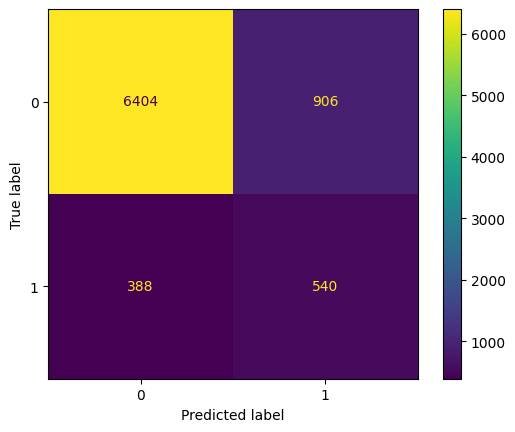

In [152]:
cm = confusion_matrix(y_test, y_pred_ada)

ConfusionMatrixDisplay(confusion_matrix=cm).plot();

In [153]:
true_negative_tn = cm[0,0]
false_negative_fn = cm[1,0]
true_positive_tp = cm[1,1]
false_positive_fp = cm[0,1]

In [154]:
# Business Metrics
model_profit_base = (true_positive_tp * bank_profit).round()
model_revenue_base = (true_positive_tp * 250).round()
model_total_cost_base =  ( (false_positive_fp + true_positive_tp) * call_cost ).round()
model_conv_rate_base = (true_positive_tp / (true_positive_tp + false_positive_fp)).round(2)
model_net_profit_base = (model_profit_base - model_total_cost_base).round()
model_roi_base = (model_revenue_base/model_total_cost_base).round(2)
model_net_roi_base = (model_net_profit_base/model_total_cost_base).round(2)

print(f'Campaign model (untuned) total cost : { model_total_cost_base.round() }')
print(f'Campaign model (untuned) net profit : {model_net_profit_base.round()}')
print(f'Campaign model (untuned) conversion rate : { model_conv_rate_base.round(2)}')
print(f'Campaign model (untuned) ROI : { model_net_roi_base.round(2) }')

Campaign model (untuned) total cost : 152.0
Campaign model (untuned) net profit : 3615.0
Campaign model (untuned) conversion rate : 0.37
Campaign model (untuned) ROI : 23.78


## 4.2 AdaBoost Tuned for F2-Score

### 4.2.1. Declaring Tuning Pipeline

In [319]:
from sklearn.metrics import make_scorer
f2_scorer = make_scorer(fbeta_score, beta=2)

In [320]:
parameters = {
    'n_estimators' : [110, 115, 120, 130],
    'learning_rate' : [1.4, 1.5, 1.6, 1.7, 1.8],
    }

In [321]:
adaboost_tune_steps_f2 = pipe.steps + smote_pipe_steps + [('classifier', GridSearchCV(AdaBoostClassifier(random_state=2042), parameters, n_jobs = 1, cv = 5, scoring = f2_scorer))]
adaboost_tune_f2 = impipeline(steps=adaboost_tune_steps_f2)
adaboost_tune_f2

,steps,"[('feature engineering', ...), ('smote', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('onehot_encoding', ...), ('binary_encoding', ...), ...]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,False


### 4.2.2. Hyperparameter Tuning

In [ ]:
adaboost_tuned_f2 = adaboost_tune_f2.fit(X_train, y_train)

In [ ]:
best_model_f2 = adaboost_tuned_f2[2].best_estimator_
adaboost_best_f2 = pipe.steps + smote_pipe_steps + [('AdaBoostClassifier', best_model_f2)]
adaboost_best_pipeline_f2 = impipeline(steps=adaboost_best_f2)

adaboost_best_pipeline_f2.fit(X_train, y_train)

,steps,"[('feature engineering', ...), ('smote', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('onehot_encoding', ...), ('binary_encoding', ...), ...]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,False


In [ ]:
y_pred_tuned_ada_f2 = adaboost_best_pipeline_f2.predict(X_test)

### 4.2.3. Evaluation Metrics

In [ ]:
# Evaluate the performance
accuracy_ada_tuned_f2 = accuracy_score(y_test, y_pred_tuned_ada_f2)
precision_ada_tuned_f2 = precision_score(y_test, y_pred_tuned_ada_f2)
recall_ada_tuned_f2 = recall_score(y_test, y_pred_tuned_ada_f2)
f1_score_ada_tuned_f2 = f1_score(y_test, y_pred_tuned_ada_f2)
f2_score_ada_tuned_f2 = fbeta_score(y_test, y_pred_tuned_ada_f2, beta=2)
conv_rate_ada_tuned_f2 = conv_rate_func(y_test, y_pred_tuned_ada_f2)
roi_ada_tuned_f2 = roi_func(y_test, y_pred_tuned_ada_f2)

print("Evaluation Metrics")
ada_evaluation_tuned_f2 = {
    "Metric": ["Accuracy", "Precision", "Recall","F2 Score", "Conversion Rate", "ROI"],
    "Value": [accuracy_ada_tuned_f2, precision_ada_tuned_f2, recall_ada_tuned_f2, f2_score_ada_tuned_f2, conv_rate_ada_tuned_f2, roi_ada_tuned_f2]
}

# Create DataFrame
df_model_ada_tuned_f2 = pd.DataFrame(ada_evaluation_tuned_f2)
df_model_ada_tuned_f2

Evaluation Metrics


,Metric,Value
0,Accuracy,0.868657
1,Precision,0.422065
2,Recall,0.449353
3,F2 Score,0.443617
4,Conversion Rate,42.206478
5,ROI,27.037160


### 4.2.4. Classification Report

In [ ]:
print(classification_report(y_test, y_pred_tuned_ada_f2))

              precision    recall  f1-score   support

           0       0.93      0.92      0.93      7310
           1       0.42      0.45      0.44       928

    accuracy                           0.87      8238
   macro avg       0.68      0.69      0.68      8238
weighted avg       0.87      0.87      0.87      8238



### 4.2.5. Confusion Matrix

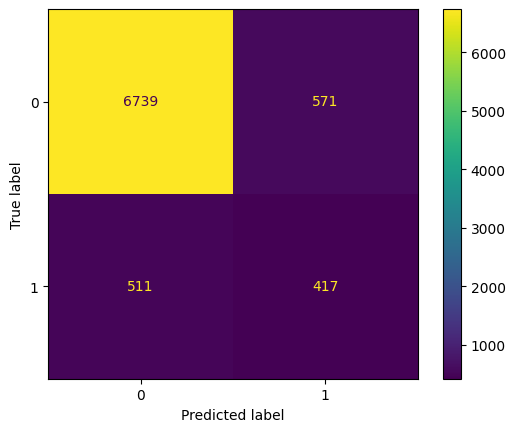

In [ ]:
cm_tuned_f2 = confusion_matrix(y_test, y_pred_tuned_ada_f2)

ConfusionMatrixDisplay(confusion_matrix=cm_tuned_f2).plot();

In [ ]:
true_negative_tn_tuned_f2 = cm_tuned_f2[0,0]
false_negative_fn_tuned_f2 = cm_tuned_f2[1,0]
true_positive_tp_tuned_f2 = cm_tuned_f2[1,1]
false_positive_fp_tuned_f2 = cm_tuned_f2[0,1]

### 4.2.6. Business Metrics

In [ ]:
model_profit_f2 = (true_positive_tp_tuned_f2 * bank_profit).round()
model_revenue_f2 = (true_positive_tp_tuned_f2 * 250).round()
model_total_cost_f2 =  ( (false_positive_fp_tuned_f2 + true_positive_tp_tuned_f2) * call_cost).round()
model_conv_rate_f2 = (true_positive_tp_tuned_f2 / (true_positive_tp_tuned_f2 + false_positive_fp_tuned_f2)).round(2)
model_net_profit_f2 = (model_profit_f2 - model_total_cost_f2).round()
model_roi_f2 = (model_revenue_f2/model_total_cost_f2).round(2)
model_net_roi_f2 = (model_net_profit_f2/model_total_cost_f2).round(2)

In [ ]:
ada_f2_summary_data = [
                        ['Total Deposit', model_revenue_f2],
                        ['Deposit Profit', model_net_profit_f2],
                        ['Expenses', model_total_cost_f2],
                        ['ROI', model_roi_f2],
                        ['Net ROI', model_net_roi_f2],
                        ['Conversion Rate', model_conv_rate_f2],
                        ]
ada_f2_summary = pd.DataFrame(ada_f2_summary_data, columns=['Metric (Ada F2 Tuned)', 'Value'])
ada_f2_summary

,Metric (Ada F2 Tuned),Value
0,Total Deposit,104250.00
1,Deposit Profit,2805.00
2,Expenses,104.00
3,ROI,1002.40
4,Net ROI,26.97
5,Conversion Rate,0.42


## 4.3 AdaBoost Tuned for F1-Score

### 4.3.1. Declaring Tuning Pipeline

In [281]:
parameters = {
    'n_estimators' : [95, 100, 105, 110],
    'learning_rate' : [0.05, 0.1, 0.5, 1.1, 1.5],
    }

In [282]:
adaboost_tune_steps_f1 = pipe.steps + smote_pipe_steps + [('classifier', GridSearchCV(AdaBoostClassifier(random_state=2042), parameters, n_jobs = 1, cv = 5, scoring = f1_score))]
adaboost_tune_f1 = impipeline(steps=adaboost_tune_steps_f1)
adaboost_tune_f1

,steps,"[('feature engineering', ...), ('smote', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('onehot_encoding', ...), ('binary_encoding', ...), ...]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,False


### 4.3.2. Hyperparameter Tuning

In [283]:
adaboost_tuned_f1 = adaboost_tune_f1.fit(X_train, y_train)

In [284]:
best_model_f1 = adaboost_tuned_f1[2].best_estimator_
adaboost_best_f1 = pipe.steps + smote_pipe_steps + [('AdaBoostClassifier', best_model_f1)]
adaboost_best_pipeline_f1 = impipeline(steps=adaboost_best_f1)

adaboost_best_pipeline_f1.fit(X_train, y_train)

,steps,"[('feature engineering', ...), ('smote', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('onehot_encoding', ...), ('binary_encoding', ...), ...]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,False


In [285]:
y_pred_tuned_ada_f1 = adaboost_best_pipeline_f1.predict(X_test)

### 4.3.3. Evaluation Metrics

In [286]:
# Evaluate the performance
accuracy_ada_tuned_f1 = accuracy_score(y_test, y_pred_tuned_ada_f1)
precision_ada_tuned_f1 = precision_score(y_test, y_pred_tuned_ada_f1)
recall_ada_tuned_f1 = recall_score(y_test, y_pred_tuned_ada_f1)
f1_score_ada_tuned_f1 = f1_score(y_test, y_pred_tuned_ada_f1)
f2_score_ada_tuned_f1 = fbeta_score(y_test, y_pred_tuned_ada_f1, beta=2)
conv_rate_ada_tuned_f1 = conv_rate_func(y_test, y_pred_tuned_ada_f1)
roi_ada_tuned_f1 = roi_func(y_test, y_pred_tuned_ada_f1)

print("Evaluation Metrics")
ada_evaluation_tuned_f1 = {
    "Metric": ["Accuracy", "Precision", "Recall","F2 Score", "Conversion Rate", "ROI"],
    "Value": [accuracy_ada_tuned_f1, precision_ada_tuned_f1, recall_ada_tuned_f1, f2_score_ada_tuned_f1, conv_rate_ada_tuned_f1, roi_ada_tuned_f1]
}

# Create DataFrame
df_model_ada_tuned_f1 = pd.DataFrame(ada_evaluation_tuned_f1)
df_model_ada_tuned_f1

Evaluation Metrics


,Metric,Value
0,Accuracy,0.869022
1,Precision,0.428975
2,Recall,0.491379
3,F2 Score,0.477487
4,Conversion Rate,42.897460
5,ROI,27.496170


### 4.3.4. Classification Report

In [287]:
print(classification_report(y_test, y_pred_tuned_ada_f1))

              precision    recall  f1-score   support

           0       0.93      0.92      0.93      7310
           1       0.43      0.49      0.46       928

    accuracy                           0.87      8238
   macro avg       0.68      0.70      0.69      8238
weighted avg       0.88      0.87      0.87      8238



### 4.3.5. Confusion Matrix

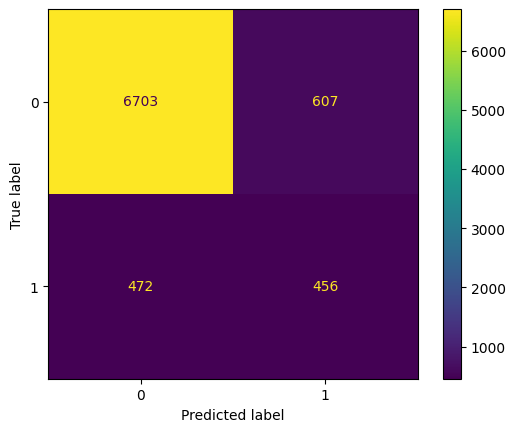

In [288]:
cm_tuned_f1 = confusion_matrix(y_test, y_pred_tuned_ada_f1)

ConfusionMatrixDisplay(confusion_matrix=cm_tuned_f1).plot();

In [289]:
true_negative_tn_tuned_f1 = cm_tuned_f1[0,0]
false_negative_fn_tuned_f1 = cm_tuned_f1[1,0]
true_positive_tp_tuned_f1 = cm_tuned_f1[1,1]
false_positive_fp_tuned_f1 = cm_tuned_f1[0,1]

### 4.3.6. Business Metrics

In [290]:
model_profit_f1     = ( (true_positive_tp_tuned_f1 * bank_profit) ).round()
model_revenue_f1     = ( (true_positive_tp_tuned_f1 * 250) ).round()
model_total_cost_f1 = ( (false_positive_fp_tuned_f1 + true_positive_tp_tuned_f1) * call_cost ).round()
model_conv_rate_f1  = ( true_positive_tp_tuned_f1 / (true_positive_tp_tuned_f1 + false_positive_fp_tuned_f1) ).round(2)
model_net_profit_f1 = ( model_profit_f1 - model_total_cost_f1 ).round()
model_net_revenue_f1 = ( model_revenue_f1 - model_total_cost_f1 ).round()
model_roi_f1    = ( model_revenue_f1/model_total_cost_f1 ).round(2)
model_net_roi_f1    = ( model_net_profit_f1/model_total_cost_f1 ).round(2)

In [291]:
ada_f1_summary_data = [
                        ['Total Deposit', model_revenue_f1],
                        ['Deposit Profit', model_net_profit_f1],
                        ['Expenses', model_total_cost_f1],
                        ['ROI', model_roi_f1],
                        ['Net ROI', model_net_roi_f1],
                        ['Conversion Rate', model_conv_rate_f1],
                        ]
ada_f1_summary = pd.DataFrame(ada_f1_summary_data, columns=['Metric (Ada F2 Tuned)', 'Value'])
ada_f1_summary

,Metric (Ada F2 Tuned),Value
0,Total Deposit,114000.00
1,Deposit Profit,3070.00
2,Expenses,111.00
3,ROI,1027.03
4,Net ROI,27.66
5,Conversion Rate,0.43


## 4.4 LogisticRegression Tuned for F2-Score

### 4.4.1 Declaring Tuning Pipeline

In [306]:
from sklearn.metrics import make_scorer
f2_scorer = make_scorer(fbeta_score, beta=2)

In [307]:
parameters = {'penalty':['l1','l2','elasticnet','none'],
    'C' : np.logspace(-1,1,4),
    'solver': [
                # 'lbfgs','newton-cg','liblinear',
            #    'sag',
               'saga'
               ],
    'max_iter'  : [
        75,
        100,
        125,
        150
        ]
}

In [308]:
logreg_tune_steps_f2 = pipe.steps + smote_pipe_steps + [('classifier', GridSearchCV(LogisticRegression(random_state=2042), parameters, n_jobs = 1, cv = 5, scoring = f2_scorer))]
logreg_tune_f2 = impipeline(steps=logreg_tune_steps_f2)
logreg_tune_f2

,steps,"[('feature engineering', ...), ('smote', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('onehot_encoding', ...), ('binary_encoding', ...), ...]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,False


### 4.4.2. Hyperparameter Tuning

In [309]:
logreg_tuned_f2 = logreg_tune_f2.fit(X_train, y_train)

In [310]:
best_model_lr_f2 = logreg_tuned_f2[2].best_estimator_
logreg_best_f2 = pipe.steps + smote_pipe_steps + [('LogisticRegression', best_model_lr_f2)]
logreg_best_pipeline_f2 = impipeline(steps=logreg_best_f2)

logreg_best_pipeline_f2.fit(X_train, y_train)

,steps,"[('feature engineering', ...), ('smote', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('onehot_encoding', ...), ('binary_encoding', ...), ...]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,False


In [311]:
y_pred_tuned_logreg_f2 = logreg_best_pipeline_f2.predict(X_test)

### 4.4.3. Evaluation Metrics

In [312]:
# Evaluate the performance
accuracy_lr_tuned_f2 = accuracy_score(y_test, y_pred_tuned_logreg_f2)
precision_lr_tuned_f2 = precision_score(y_test, y_pred_tuned_logreg_f2)
recall_lr_tuned_f2 = recall_score(y_test, y_pred_tuned_logreg_f2)
f1_score_lr_tuned_f2 = f1_score(y_test, y_pred_tuned_logreg_f2)
f2_score_lr_tuned_f2 = fbeta_score(y_test, y_pred_tuned_logreg_f2, beta=2)
conv_rate_lr_tuned_f2 = conv_rate_func(y_test, y_pred_tuned_logreg_f2)
roi_lr_tuned_f2 = roi_func(y_test, y_pred_tuned_logreg_f2)

print("Evaluation Metrics")
lr_evaluation_tuned_f2 = {
    "Metric": ["Accuracy", "Precision", "Recall","F2 Score", "Conversion Rate", "ROI"],
    "Value": [accuracy_lr_tuned_f2, precision_lr_tuned_f2, recall_lr_tuned_f2, f2_score_lr_tuned_f2, conv_rate_lr_tuned_f2, roi_lr_tuned_f2]
}

# Create DataFrame
df_model_lr_tuned_f2 = pd.DataFrame(lr_evaluation_tuned_f2)
df_model_lr_tuned_f2

Evaluation Metrics


,Metric,Value
0,Accuracy,0.712066
1,Precision,0.233383
2,Recall,0.681034
3,F2 Score,0.492212
4,Conversion Rate,23.338257
5,ROI,14.503271


### 4.4.4. Classification Report

In [313]:
print(classification_report(y_test, y_pred_tuned_logreg_f2))

              precision    recall  f1-score   support

           0       0.95      0.72      0.82      7310
           1       0.23      0.68      0.35       928

    accuracy                           0.71      8238
   macro avg       0.59      0.70      0.58      8238
weighted avg       0.87      0.71      0.76      8238



### 4.4.5. Confusion Matrix

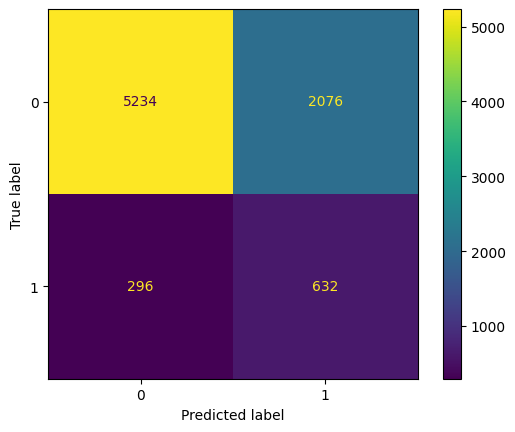

In [314]:
cm_tuned_f2_lr = confusion_matrix(y_test, y_pred_tuned_logreg_f2)

ConfusionMatrixDisplay(confusion_matrix=cm_tuned_f2_lr).plot();

In [315]:
true_negative_tn_tuned_f2_lr = cm_tuned_f2_lr[0,0]
false_negative_fn_tuned_f2_lr = cm_tuned_f2_lr[1,0]
true_positive_tp_tuned_f2_lr = cm_tuned_f2_lr[1,1]
false_positive_fp_tuned_f2_lr = cm_tuned_f2_lr[0,1]

### 4.4.6. Business Metrics

In [316]:
model_profit_f2_lr = (true_positive_tp_tuned_f2_lr * bank_profit).round()
model_revenue_f2_lr = (true_positive_tp_tuned_f2_lr * 250).round()
model_total_cost_f2_lr =  ( (false_positive_fp_tuned_f2_lr + true_positive_tp_tuned_f2_lr) * call_cost).round()
model_conv_rate_f2_lr = (true_positive_tp_tuned_f2_lr / (true_positive_tp_tuned_f2_lr + false_positive_fp_tuned_f2_lr)).round(2)
model_net_profit_f2_lr = (model_profit_f2_lr - model_total_cost_f2_lr).round()
model_roi_f2_lr = (model_revenue_f2_lr/model_total_cost_f2_lr).round(2)
model_net_roi_f2_lr = (model_net_profit_f2_lr/model_total_cost_f2_lr).round(2)

In [317]:
lr_f2_summary_data = [
                        ['Total Deposit', model_revenue_f2_lr],
                        ['Deposit Profit', model_net_profit_f2_lr],
                        ['Expenses', model_total_cost_f2_lr],
                        ['ROI', model_roi_f2_lr],
                        ['Net ROI', model_net_roi_f2_lr],
                        ['Conversion Rate', model_conv_rate_f2_lr],
                        ]
lr_f2_summary = pd.DataFrame(lr_f2_summary_data, columns=['Metric (Ada F2 Tuned)', 'Value'])
lr_f2_summary

,Metric (Ada F2 Tuned),Value
0,Total Deposit,158000.00
1,Deposit Profit,4124.00
2,Expenses,284.00
3,ROI,556.34
4,Net ROI,14.52
5,Conversion Rate,0.23


# 5. Business Metrics Performance Summary

In [318]:
business_summary_data = [['Non Model', unseen_total_cost_sum, unseen_revenue, unseen_net_profit, unseen_conv_rate, unseen_roi, unseen_net_roi ],
        ['Model AdaBoost Untuned', model_total_cost_base, model_revenue_base, model_net_profit_base, model_conv_rate_base, model_roi_base, model_net_roi_base ],
        ['Model AdaBoost F2 Tuned', model_total_cost_f2, model_revenue_f2, model_net_profit_f2, model_conv_rate_f2, model_roi_f2, model_net_roi_f2],
        ['Model AdaBoost F1 Tuned', model_total_cost_f1, model_revenue_f1, model_net_profit_f1, model_conv_rate_f1, model_roi_f1, model_net_roi_f1],
        ['Model LogReg F2 Tuned', model_total_cost_f2_lr, model_revenue_f2_lr, model_net_profit_f2_lr, model_conv_rate_f2_lr, model_roi_f2_lr, model_net_roi_f2_lr]]
business_summary = pd.DataFrame(business_summary_data, columns=['Type', 'Total Cost', 'Revenue', 'Net Profit', 'Conversion Rate', 'ROI', 'Net ROI'])
business_summary

,Type,Total Cost,Revenue,Net Profit,Conversion Rate,ROI,Net ROI
0,Non Model,2578.0,232000,3895.0,0.11,88.99,1.51
1,Model AdaBoost Untuned,152.0,135000,3615.0,0.37,888.16,23.78
2,Model AdaBoost F2 Tuned,104.0,104250,2805.0,0.42,1002.40,26.97
3,Model AdaBoost F1 Tuned,111.0,114000,3070.0,0.43,1027.03,27.66
4,Model LogReg F2 Tuned,284.0,158000,4124.0,0.23,556.34,14.52


# 6. Feature Importance

In [190]:
column_names = pipecheck.named_steps['feature engineering'].get_feature_names_out()

## 6.1. Feature Importance (Untuned Ada)

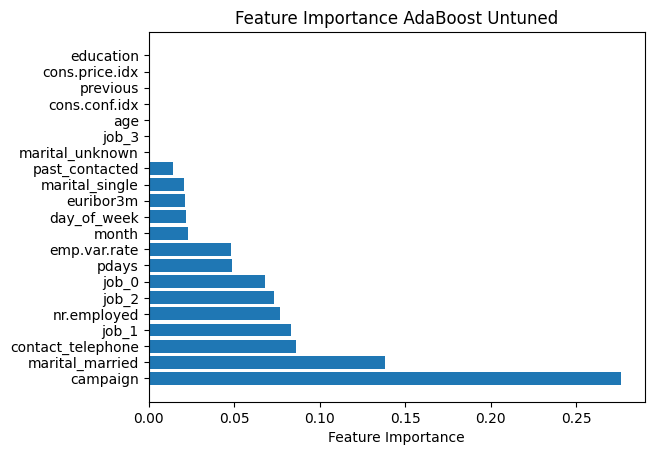

In [191]:
feature_importances_ada_untuned = adaboost_smote_pipeline.named_steps['AdaBoostClassifier'].feature_importances_

feature_importance_ada_untuned_df = pd.DataFrame({
        'Feature': column_names,
        'Importance': feature_importances_ada_untuned
    })
sorted_ada_untuned_df = feature_importance_ada_untuned_df.sort_values(by='Importance', ascending=False)

plt.barh(sorted_ada_untuned_df['Feature'], sorted_ada_untuned_df['Importance'])
plt.xlabel('Feature Importance')
plt.title('Feature Importance AdaBoost Untuned')
plt.show()

## 6.2. Feature Importance (Ada F2)

In [192]:
# feature_importances = best_model_f2.feature_importances_
feature_importances = adaboost_best_pipeline_f2.named_steps['AdaBoostClassifier'].feature_importances_
# np.array(feature_importances).tolist()
# len(feature_importances)
# feature_importances

In [193]:
pipecheck = impipeline(steps=[
    ('feature engineering', preprocessor)
    ])


X_test_transformed = pipecheck.fit_transform(X_test)
X_test_transformed_array = pd.DataFrame(X_test_transformed)
# len(pipecheck.named_steps['feature engineering'].get_feature_names_out())
column_names = pipecheck.named_steps['feature engineering'].get_feature_names_out()
# column_names

In [194]:
feature_importance_df = pd.DataFrame({
        'Feature': column_names,
        'Importance': feature_importances
    })
sorted_feature_importance = feature_importance_df.sort_values(by='Importance', ascending=False)
print(sorted_feature_importance)

              Feature  Importance
9            campaign    0.256892
20        day_of_week    0.214711
6               job_2    0.068018
7               job_3    0.056535
5               job_1    0.052587
3   contact_telephone    0.048017
19        nr.employed    0.045825
1      marital_single    0.041227
4               job_0    0.040125
0     marital_married    0.035506
17              month    0.034980
16     cons.price.idx    0.022365
15          education    0.020825
10              pdays    0.020331
13     past_contacted    0.018903
18          euribor3m    0.013403
12      cons.conf.idx    0.005462
8                 age    0.004289
2     marital_unknown    0.000000
11           previous    0.000000
14       emp.var.rate    0.000000


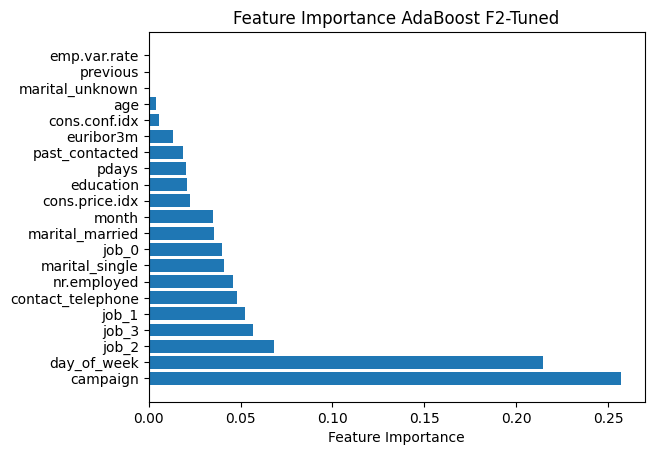

In [195]:
# df_importance = pd.DataFrame(list(zip(column_names, feature_importances)),
#                columns =['column', 'importance'])
# df_importance = df_importance.sort_values('importance', ascending=False)

###

plt.barh(sorted_feature_importance['Feature'], sorted_feature_importance['Importance'])
plt.xlabel('Feature Importance')
plt.title('Feature Importance AdaBoost F2-Tuned')
plt.show()

In [196]:

df_cek_job = df.copy()

encoder = ce.BinaryEncoder(cols=['job'])

# Encoded
encoded_df = encoder.fit_transform(df)

# Old column 
old_df = encoder.inverse_transform(encoded_df)

In [197]:
encoded_job = encoded_df.iloc[ :, 1:5].copy()
encoded_job

,job_0,job_1,job_2,job_3
0,0,0,0,1
1,0,0,1,0
2,0,0,1,0
3,0,0,1,1
4,0,0,1,0
...,...,...,...,...
41183,0,1,1,0
41184,0,1,0,0
41185,0,1,1,0
41186,0,1,0,1


In [198]:
df_job_only = df_cek_job['job'].copy()

In [199]:
job_check_df = pd.concat([df_job_only, encoded_job], axis=1)
job_check_df.drop_duplicates()

,job,job_0,job_1,job_2,job_3
0,housemaid,0,0,0,1
1,services,0,0,1,0
3,admin.,0,0,1,1
7,blue-collar,0,1,0,0
8,technician,0,1,0,1
15,retired,0,1,1,0
19,management,0,1,1,1
20,unemployed,1,0,0,0
27,self-employed,1,0,0,1
29,unknown,1,0,1,0


## 6.3. Feature Importance (Ada F1)

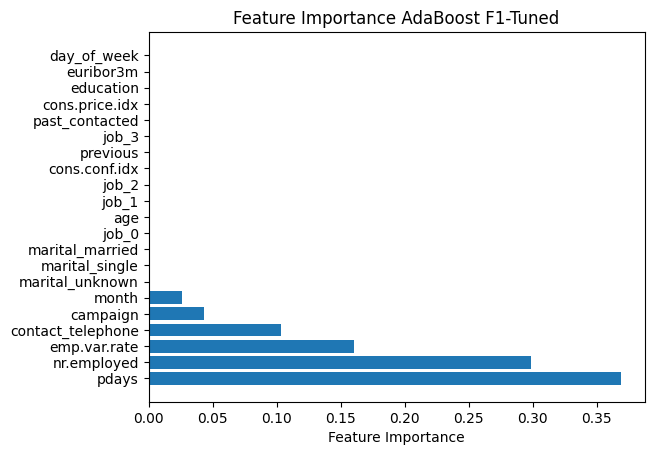

In [200]:
feature_importances_ada_f1 = adaboost_best_pipeline_f1.named_steps['AdaBoostClassifier'].feature_importances_

feature_importances_ada_f1_df = pd.DataFrame({
        'Feature': column_names,
        'Importance': feature_importances_ada_f1
    })
sorted_ada_f1_df = feature_importances_ada_f1_df.sort_values(by='Importance', ascending=False)

plt.barh(sorted_ada_f1_df['Feature'], sorted_ada_f1_df['Importance'])
plt.xlabel('Feature Importance')
plt.title('Feature Importance AdaBoost F1-Tuned')
plt.show()

## 6.4. Feature Importance (LogReg F2)

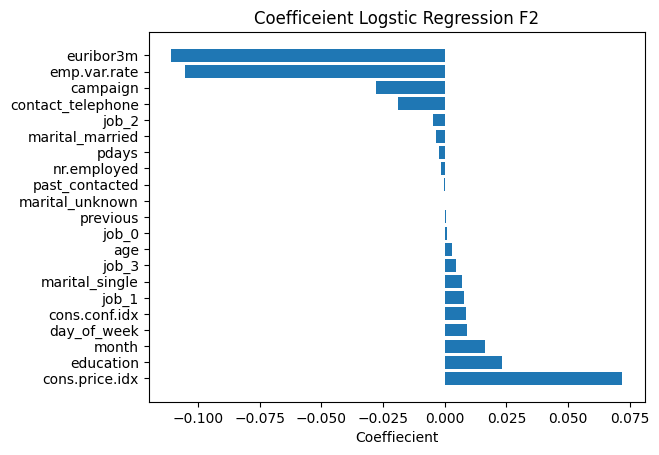

In [201]:
feature_importances_logreg_f2 = logreg_best_pipeline_f2.named_steps['LogisticRegression'].coef_[0]

feature_importances_logreg_f2_df = pd.DataFrame({
        'Feature': column_names,
        'Importance': feature_importances_logreg_f2
    })
sorted_logreg_f2_df = feature_importances_logreg_f2_df.sort_values(by='Importance', ascending=False)

plt.barh(sorted_logreg_f2_df['Feature'], sorted_logreg_f2_df['Importance'])
plt.xlabel('Coeffiecient')
plt.title('Coefficeient Logstic Regression F2')
plt.show()

Coefficient Magnitude

The easiest way to determine the significance of a feature in logistic regression is to look at the size of the coefficients (β). Features with higher absolute coefficient values are deemed more significant. Each coefficient represents the change in the log odds of the outcome for a one-unit change in the predictor variable, holding all other variables constant.

    Positive Coefficient: Indicates that an increase in the predictor variable increases the log odds of the positive class.
    Negative Coefficient: Indicates that an increase in the predictor variable decreases the log odds of the positive class.

For standardized features, the magnitude of the coefficients can be directly compared to assess the relative importance of each feature.

# 7. Counterfactual

## 7.1. Counterfactual Set Up

In [202]:
cf_df = X_train.copy()

# Specify Numerical Columns
numeric_features = list(cf_df.select_dtypes(include=['float64', 'int64']).columns)

cf_df['Deposit'] = y_train.reset_index(drop=True)

# Define the Data Interface
data_interface = dice_ml.Data(dataframe=cf_df, continuous_features=numeric_features, outcome_name='Deposit')

# Define the Model Interface
model_interface = dice_ml.Model(model=adaboost_best_pipeline_f2, backend='sklearn')

# Initialize Dice
dice = Dice(data_interface, model_interface)

In [203]:
X_test

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,past_contacted
28144,42,technician,married,4,no,no,yes,cellular,4,1,...,2,999,0,nonexistent,-1.8,93.075,-47.1,1.466,5099.1,0
6358,50,admin.,single,7,no,no,no,telephone,5,2,...,3,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,0
13838,33,admin.,divorced,5,no,yes,no,cellular,7,5,...,1,999,0,nonexistent,1.4,93.918,-42.7,4.963,5228.1,0
31539,32,blue-collar,married,4,no,yes,no,cellular,5,4,...,1,999,0,nonexistent,-1.8,92.893,-46.2,1.327,5099.1,0
1589,55,technician,married,4,unknown,unknown,unknown,telephone,5,5,...,2,999,0,nonexistent,1.1,93.994,-36.4,4.855,5191.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16776,41,technician,single,7,no,yes,yes,cellular,7,4,...,1,999,0,nonexistent,1.4,93.918,-42.7,4.962,5228.1,0
12598,28,services,single,5,no,yes,no,cellular,7,1,...,1,999,0,nonexistent,1.4,93.918,-42.7,4.960,5228.1,0
22049,31,technician,single,5,no,yes,yes,cellular,8,3,...,3,999,0,nonexistent,1.4,93.444,-36.1,4.964,5228.1,0
3512,32,services,married,5,unknown,yes,no,telephone,5,4,...,3,999,0,nonexistent,1.1,93.994,-36.4,4.860,5191.0,0


In [204]:


# Generate Counterfactuals
pd.set_option('display.max_columns', None)
cf = dice.generate_counterfactuals(X_test.reset_index(drop=True).loc[[98]], desired_class='opposite', total_CFs=3,
                                   features_to_vary='all')

# Display
cf.visualize_as_dataframe(show_only_changes=True)

# Store Generated Counterfactual Instance
counterfact_sample1 = cf.cf_examples_list[0].final_cfs_df



100%|██████████| 1/1 [00:03<00:00,  3.60s/it]

Query instance (original outcome : 0)


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,duration,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,past_contacted,Deposit
0,27,admin.,single,5,no,yes,no,cellular,5,1,156,1,999,0,nonexistent,-1.8,92.892998,-46.200001,1.299,5099.100098,0,0



Diverse Counterfactual set (new outcome: 1)


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,duration,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,past_contacted,Deposit
0,-,-,-,-,-,-,-,-,3,-,-,-,-,-,-,-,-,-,-,-,-,1
1,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,1
2,-,-,-,-,-,-,-,-,-,-,-,-,6,-,-,-,-,-,-,-,-,1


## 7.2 Generating Probabilities

### 7.2.1. Generating Counterfactual (1)

In [205]:
# Get the probability for the positive class (Deposit) for the counterfactual
probability_sample1 = adaboost_best_pipeline_f2.predict_proba(counterfact_sample1)[0, 1]
probability_sample1

np.float64(0.5054587252016197)

In [206]:
# Generate Counterfactuals
pd.set_option('display.max_columns', None)
cf = dice.generate_counterfactuals(X_test.reset_index(drop=True).loc[[6598]], desired_class='opposite', total_CFs=3,
                                   features_to_vary='all')

# Display
cf.visualize_as_dataframe(show_only_changes=True)

# Store Generated Counterfactual Instance
counterfact_sample2 = cf.cf_examples_list[0].final_cfs_df

  0%|          | 0/1 [00:00<?, ?it/s]

100%|██████████| 1/1 [00:00<00:00,  1.05it/s]

Query instance (original outcome : 0)


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,duration,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,past_contacted,Deposit
0,35,technician,single,6,no,yes,no,cellular,5,1,213,4,999,0,nonexistent,-1.8,92.892998,-46.200001,1.244,5099.100098,0,0



Diverse Counterfactual set (new outcome: 1)


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,duration,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,past_contacted,Deposit
0,-,-,-,-,-,-,yes,-,-,-,-,-,-,-,-,-,-,-,-,-,-,1
1,-,services,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,1
2,-,-,-,-,-,-,unknown,-,4,-,-,-,-,-,-,-,-,-,-,-,-,1


### 7.2.2. Generating Counterfactual (2)

In [207]:
# Get the probability for the positive class (Deposit) for the counterfactual
probability_sample2 = adaboost_best_pipeline_f2.predict_proba(counterfact_sample2)[0, 1]
probability_sample2

np.float64(0.510561974780488)

In [208]:
# Generate Counterfactuals
pd.set_option('display.max_columns', None)
cf = dice.generate_counterfactuals(X_test.reset_index(drop=True).loc[[8234]], desired_class='opposite', total_CFs=3,
                                   features_to_vary='all')

# Display
cf.visualize_as_dataframe(show_only_changes=True)

# Store Generated Counterfactual Instance
counterfact_sample3 = cf.cf_examples_list[0].final_cfs_df

  0%|          | 0/1 [00:00<?, ?it/s]

100%|██████████| 1/1 [00:00<00:00,  1.02it/s]

Query instance (original outcome : 0)


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,duration,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,past_contacted,Deposit
0,28,services,single,5,no,yes,no,cellular,7,1,98,1,999,0,nonexistent,1.4,93.917999,-42.700001,4.96,5228.100098,0,0



Diverse Counterfactual set (new outcome: 1)


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,duration,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,past_contacted,Deposit
0,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,0.3,-,-,-,-,-,1
1,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-43.3,-,-,-,1
2,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,1


### 7.2.3. Generating Counterfactual (3)

In [209]:
# Get the probability for the positive class (Deposit) for the counterfactual
probability_sample3 = adaboost_best_pipeline_f2.predict_proba(counterfact_sample3)[0, 1]
probability_sample3

np.float64(0.5076039629831111)

In [210]:
# Generate Counterfactuals
pd.set_option('display.max_columns', None)
cf = dice.generate_counterfactuals(X_test.reset_index(drop=True).loc[[1495]], desired_class='opposite', total_CFs=1,
                                   features_to_vary='all')

# Display
cf.visualize_as_dataframe(show_only_changes=True)

# Store Generated Counterfactual Instance
counterfact_sample4 = cf.cf_examples_list[0].final_cfs_df

100%|██████████| 1/1 [00:01<00:00,  1.13s/it]

Query instance (original outcome : 0)


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,duration,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,past_contacted,Deposit
0,27,admin.,single,6,no,no,no,cellular,7,2,46,1,999,0,nonexistent,1.4,93.917999,-42.700001,4.962,5228.100098,0,0



Diverse Counterfactual set (new outcome: 1)


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,duration,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,past_contacted,Deposit
0,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-0.5,-,-,-,-,-,1


### 7.2.4. Generating Counterfactual (4)

In [211]:
# Get the probability for the positive class (Deposit) for the counterfactual
probability_sample4 = adaboost_best_pipeline_f2.predict_proba(counterfact_sample4)[0, 1]
probability_sample4

np.float64(0.5094725145402966)

In [212]:
# Generate Counterfactuals
cf = dice.generate_counterfactuals(X_test.reset_index(drop=True).loc[[7123]], desired_class='opposite', total_CFs=3,
                                   features_to_vary='all')

# Display
cf.visualize_as_dataframe(show_only_changes=True)

# Store Generated Counterfactual Instance
counterfact = cf.cf_examples_list[0].final_cfs_df

100%|██████████| 1/1 [00:01<00:00,  1.54s/it]

Query instance (original outcome : 0)


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,duration,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,past_contacted,Deposit
0,32,self-employed,married,4,no,yes,yes,telephone,6,2,408,2,999,0,nonexistent,1.4,94.464996,-41.799999,4.961,5228.100098,0,0



Diverse Counterfactual set (new outcome: 1)


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,duration,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,past_contacted,Deposit
0,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,1
1,-,-,-,7,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,1
2,-,-,-,-,-,-,-,-,-,-,-,-,-,-,failure,-,-,-,-,-,-,1
